<style>
.jp-RenderedHTMLCommon { font-size: 16px; line-height: 1.8; }
.jp-RenderedHTMLCommon h1 {
  font-family: "Segoe UI", Tahoma, Arial, sans-serif;
  color: #1a365d;
  border-bottom: 3px solid #2c5282;
  padding-bottom: 0.35em;
  margin-top: 0;
}
.jp-RenderedHTMLCommon h2 { color: #2c5282; font-weight: 600; }
.jp-RenderedHTMLCommon hr { border: none; border-top: 1px solid #e2e8f0; margin: 1.25rem 0; }
.jp-RenderedHTMLCommon table { border-collapse: collapse; }
.jp-RenderedHTMLCommon th, .jp-RenderedHTMLCommon td {
  border: 1px solid #e2e8f0; padding: 0.5rem 0.65rem;
}
.jp-RenderedHTMLCommon th { background: #ebf8ff; }
</style>

# مشروع التنبؤ بأسعار الشقق في مصر
## مسار Machine Learning للانحدار مع MLflow

---

### نظرة عامة على المشروع

هذا المشروع يطبق **Pipeline كامل للـ Machine Learning** على بيانات أسعار شقق في مصر.

**الهدف:** التنبؤ بسعر الشقة (بالجنيه المصري) انطلاقًا من خصائص مساحة، موقع، وتجهيزات.

**المراحل:**
1. **استكشاف البيانات** (EDA)
2. **تنظيف البيانات** (Data Cleaning)
3. **تجهيز البيانات** (Feature Engineering & Preprocessing)
4. **Linear Regression** مع تقييم
5. **Ridge Regression** (L2 Regularization)
6. **Lasso Regression** (L1 Regularization)
7. **ElasticNet Regression** (L1 + L2)
8. **Grid Search** لاختيار أفضل Hyperparameters
9. **MLflow Tracking** لتسجيل ومقارنة النتائج

**التقرير الرسمي المُفصَّل (عناوين الدفتر + شرح كل رسمة وأعمدة البيانات):** افتح الملف `Project_Technical_Report.html` من نفس مجلد المشروع في المتصفح.


## الخطوة 1 — استيراد المكتبات

نستورد جميع المكتبات اللازمة للمشروع:
- **pandas / numpy**: للتعامل مع البيانات
- **matplotlib / seaborn**: للرسومات البيانية  
- **sklearn**: لبناء وتقييم النماذج
- **mlflow**: لتتبع وتسجيل نتائج التجارب
- **warnings**: لإخفاء التحذيرات غير الضرورية


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn - Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Sklearn - Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

# Sklearn - Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# MLflow
import mlflow
import mlflow.sklearn

print("✅ تم استيراد جميع المكتبات بنجاح!")
print(f"Scikit-learn version: {__import__('sklearn').__version__}")
print(f"MLflow version: {mlflow.__version__}")


✅ تم استيراد جميع المكتبات بنجاح!
Scikit-learn version: 1.8.0
MLflow version: 3.12.0


## الخطوة 2 — تحميل البيانات واستكشافها (EDA)

### وصف مجموعة البيانات
الداتا دي بتمثل **أسعار شقق في مصر** وبتحتوي على 1000 شقة و 11 عمود:

| العمود | الوصف | النوع |
|--------|--------|-------|
| المساحة_متر_مربع | مساحة الشقة بالمتر المربع | رقم |
| عدد_الغرف | عدد غرف النوم | رقم صحيح |
| عمر_المنزل_سنة | عمر العقار بالسنوات | رقم |
| الطابق | رقم الطابق | رقم صحيح |
| المسافة_من_المترو_كم | المسافة من أقرب محطة مترو | رقم |
| يوجد_جراج | هل يوجد جراج؟ (0 أو 1) | ثنائي |
| يوجد_حديقة | هل يوجد حديقة؟ (0 أو 1) | ثنائي |
| تقييم_الحي | تقييم الحي من 1 إلى 10 | رقم |
| عدد_الحمامات | عدد الحمامات | رقم صحيح |
| تم_التجديد | هل تم تجديد الشقة؟ (0 أو 1) | ثنائي |
| **السعر_جنيه** | **سعر الشقة (Target)** | **رقم** |


In [2]:
# تحميل الداتا
df = pd.read_csv('house_prices_egypt.csv', encoding='utf-8-sig')

print("=" * 60)
print("📊 أبعاد الداتا (Rows, Columns):")
print(f"   عدد الصفوف: {df.shape[0]:,}")
print(f"   عدد الأعمدة: {df.shape[1]}")
print("=" * 60)
print("\n🔍 أول 5 صفوف من الداتا:")
df.head()


📊 أبعاد الداتا (Rows, Columns):
   عدد الصفوف: 1,000
   عدد الأعمدة: 11

🔍 أول 5 صفوف من الداتا:


,المساحة_متر_مربع,عدد_الغرف,عمر_المنزل_سنة,الطابق,المسافة_من_المترو_كم,يوجد_جراج,يوجد_حديقة,تقييم_الحي,عدد_الحمامات,تم_التجديد,السعر_جنيه
0,174.835708,4,16.0,2,2.534004,1,0,8.0,3,0,1569784
1,143.086785,1,5.0,6,2.326996,1,0,3.0,2,0,1216747
2,182.384427,3,3.0,11,2.812111,1,1,3.0,3,0,1612739
3,226.151493,5,19.0,2,4.162575,1,0,1.0,1,1,1840145
4,138.292331,3,26.0,13,3.176191,0,0,3.0,1,0,1126035


In [3]:
# معلومات عامة عن الداتا
print("📋 أنواع البيانات ومعلومات أساسية:")
df.info()


📋 أنواع البيانات ومعلومات أساسية:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   المساحة_متر_مربع      970 non-null    float64
 1   عدد_الغرف             1000 non-null   int64  
 2   عمر_المنزل_سنة        975 non-null    float64
 3   الطابق                1000 non-null   int64  
 4   المسافة_من_المترو_كم  980 non-null    float64
 5   يوجد_جراج             1000 non-null   int64  
 6   يوجد_حديقة            1000 non-null   int64  
 7   تقييم_الحي            985 non-null    float64
 8   عدد_الحمامات          1000 non-null   int64  
 9   تم_التجديد            1000 non-null   int64  
 10  السعر_جنيه            1000 non-null   int64  
dtypes: float64(4), int64(7)
memory usage: 86.1 KB


In [4]:
# إحصاءات وصفية
print("📈 الإحصاءات الوصفية:")
df.describe().round(2)


📈 الإحصاءات الوصفية:


,المساحة_متر_مربع,عدد_الغرف,عمر_المنزل_سنة,الطابق,المسافة_من_المترو_كم,يوجد_جراج,يوجد_حديقة,تقييم_الحي,عدد_الحمامات,تم_التجديد,السعر_جنيه
count,970.00,1000.00,975.00,1000.00,980.00,1000.00,1000.00,985.00,1000.00,1000.00,1000.00
mean,151.40,3.56,19.85,7.44,2.07,0.57,0.34,5.58,1.97,0.41,1402412.98
std,48.78,1.70,11.43,4.06,1.37,0.50,0.48,3.02,0.84,0.49,711554.87
min,40.00,1.00,0.00,1.00,0.10,0.00,0.00,1.00,1.00,0.00,352662.00
25%,118.26,2.00,10.00,4.00,0.98,0.00,0.00,3.00,1.00,0.00,1059816.50
50%,151.32,4.00,20.00,7.00,2.00,1.00,0.00,6.00,2.00,0.00,1333036.50
75%,182.68,5.00,29.50,11.00,3.04,1.00,1.00,8.00,3.00,1.00,1594675.25
max,342.64,6.00,39.00,14.00,6.59,1.00,1.00,10.00,3.00,1.00,7259430.00


## الخطوة 3 — تحليل القيم المفقودة (Missing Values)

**لماذا نتحقق من القيم المفقودة؟**
القيم المفقودة بتأثر سلبًا على النماذج، فلازم نعالجها قبل الـ Training.


❌ الأعمدة التي تحتوي على قيم مفقودة:
                      عدد القيم المفقودة  النسبة المئوية (%)
المساحة_متر_مربع                      30                 3.0
عمر_المنزل_سنة                        25                 2.5
المسافة_من_المترو_كم                  20                 2.0
تقييم_الحي                            15                 1.5


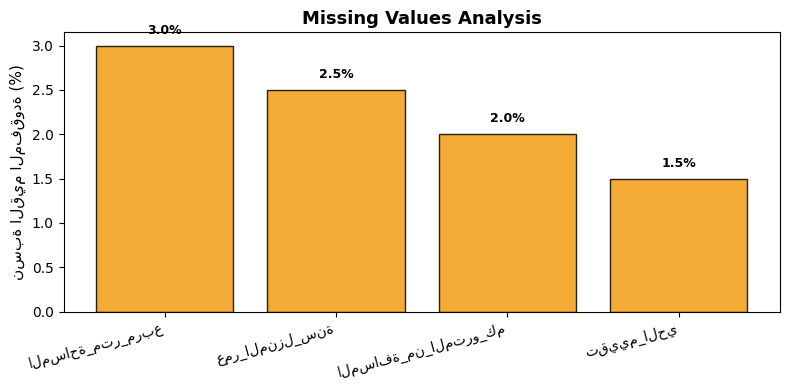

✅ تم حفظ الرسم


In [5]:
# تحليل القيم المفقودة
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'عدد القيم المفقودة': missing,
    'النسبة المئوية (%)': missing_pct
}).query('`عدد القيم المفقودة` > 0')

print("❌ الأعمدة التي تحتوي على قيم مفقودة:")
print(missing_df)

# رسم مرئي
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#e74c3c' if p > 3 else '#f39c12' for p in missing_df['النسبة المئوية (%)']]
bars = ax.bar(range(len(missing_df)), missing_df['النسبة المئوية (%)'], color=colors, edgecolor='black', alpha=0.85)
ax.set_xticks(range(len(missing_df)))
ax.set_xticklabels(missing_df.index, rotation=15, ha='right', fontsize=10)
ax.set_ylabel('نسبة القيم المفقودة (%)', fontsize=11)
ax.set_title('Missing Values Analysis', fontsize=13, fontweight='bold')
for bar, val in zip(bars, missing_df['النسبة المئوية (%)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{val}%', 
            ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('missing_values.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ تم حفظ الرسم")


## الخطوة 4 — تحليل القيم الشاذة (Outliers)

### ما هي الـ Outliers؟
الـ **Outliers** هي قيم شاذة بعيدة جدًا عن باقي البيانات، بتأثر على دقة النموذج.

### طريقة IQR (Interquartile Range):
$$IQR = Q3 - Q1$$
$$\text{Lower Bound} = Q1 - 1.5 \times IQR$$
$$\text{Upper Bound} = Q3 + 1.5 \times IQR$$

أي قيمة خارج هذا النطاق تُعتبر Outlier.


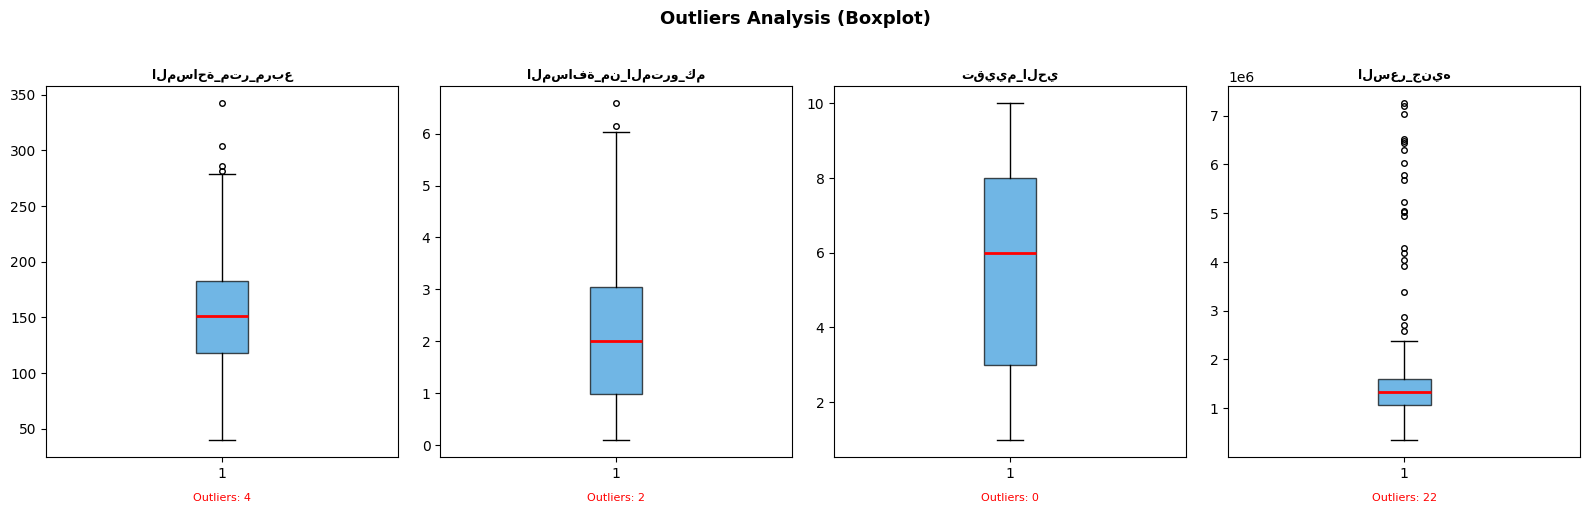

📊 تحليل Outliers في عمود السعر:
   Q1 = 1,059,816 جنيه
   Q3 = 1,594,675 جنيه
   IQR = 534,859
   الحد الأدنى = 257,528
   الحد الأعلى = 2,396,963
   عدد الـ Outliers = 22


In [6]:
# تحليل Outliers باستخدام Boxplot
numeric_cols = ['المساحة_متر_مربع', 'المسافة_من_المترو_كم', 'تقييم_الحي', 'السعر_جنيه']

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for i, col in enumerate(numeric_cols):
    data = df[col].dropna()
    axes[i].boxplot(data, patch_artist=True, 
                    boxprops=dict(facecolor='#3498db', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', color='orange', markersize=4))
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].set_xlabel('')
    
    # حساب عدد الـ outliers
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    outliers = data[(data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)]
    axes[i].text(0.5, -0.12, f'Outliers: {len(outliers)}', 
                transform=axes[i].transAxes, ha='center', fontsize=8, color='red')

plt.suptitle('Outliers Analysis (Boxplot)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outliers_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# حساب الـ Outliers في السعر
Q1 = df['السعر_جنيه'].quantile(0.25)
Q3 = df['السعر_جنيه'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print(f"📊 تحليل Outliers في عمود السعر:")
print(f"   Q1 = {Q1:,.0f} جنيه")
print(f"   Q3 = {Q3:,.0f} جنيه")
print(f"   IQR = {IQR:,.0f}")
print(f"   الحد الأدنى = {lower:,.0f}")
print(f"   الحد الأعلى = {upper:,.0f}")
print(f"   عدد الـ Outliers = {len(df[(df['السعر_جنيه'] < lower) | (df['السعر_جنيه'] > upper)])}")


## الخطوة 5 — تنظيف البيانات (Data Cleaning)

### الخطوات:
1. **معالجة القيم المفقودة**: استخدام الـ Median للأعمدة الرقمية (أفضل من المتوسط لأنه أقل تأثرًا بالـ Outliers)
2. **إزالة الـ Outliers**: باستخدام طريقة IQR


In [7]:
df_clean = df.copy()

# ============================
# 1. معالجة القيم المفقودة
# ============================
print("🔧 قبل المعالجة - عدد القيم المفقودة:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

# الـ Median أكثر أمانًا من الـ Mean في وجود Outliers
cols_with_missing = ['المساحة_متر_مربع', 'عمر_المنزل_سنة', 
                     'المسافة_من_المترو_كم', 'تقييم_الحي']

for col in cols_with_missing:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)
    print(f"   ✅ {col}: تم ملء القيم المفقودة بالـ Median = {median_val:.2f}")

print(f"\n✅ بعد المعالجة - إجمالي القيم المفقودة: {df_clean.isnull().sum().sum()}")

# ============================
# 2. إزالة الـ Outliers
# ============================
rows_before = len(df_clean)

# نطبق IQR على السعر فقط (التارجت الأساسي)
Q1 = df_clean['السعر_جنيه'].quantile(0.25)
Q3 = df_clean['السعر_جنيه'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_clean = df_clean[(df_clean['السعر_جنيه'] >= lower) & (df_clean['السعر_جنيه'] <= upper)]
rows_after = len(df_clean)

print(f"\n🗑️ إزالة الـ Outliers:")
print(f"   قبل: {rows_before} صف")
print(f"   بعد: {rows_after} صف")
print(f"   تم حذف: {rows_before - rows_after} صف ({(rows_before - rows_after)/rows_before*100:.1f}%)")
df_clean.reset_index(drop=True, inplace=True)
print(f"\n✅ الداتا النظيفة: {df_clean.shape}")


🔧 قبل المعالجة - عدد القيم المفقودة:
المساحة_متر_مربع        30
عمر_المنزل_سنة          25
المسافة_من_المترو_كم    20
تقييم_الحي              15
dtype: int64
   ✅ المساحة_متر_مربع: تم ملء القيم المفقودة بالـ Median = 151.32
   ✅ عمر_المنزل_سنة: تم ملء القيم المفقودة بالـ Median = 20.00
   ✅ المسافة_من_المترو_كم: تم ملء القيم المفقودة بالـ Median = 2.00
   ✅ تقييم_الحي: تم ملء القيم المفقودة بالـ Median = 6.00

✅ بعد المعالجة - إجمالي القيم المفقودة: 0

🗑️ إزالة الـ Outliers:
   قبل: 1000 صف
   بعد: 978 صف
   تم حذف: 22 صف (2.2%)

✅ الداتا النظيفة: (978, 11)


## الخطوة 6 — تحليل استكشافي بعد التنظيف (EDA)

نرسم العلاقات بين المتغيرات والسعر لنفهم الداتا أكثر.


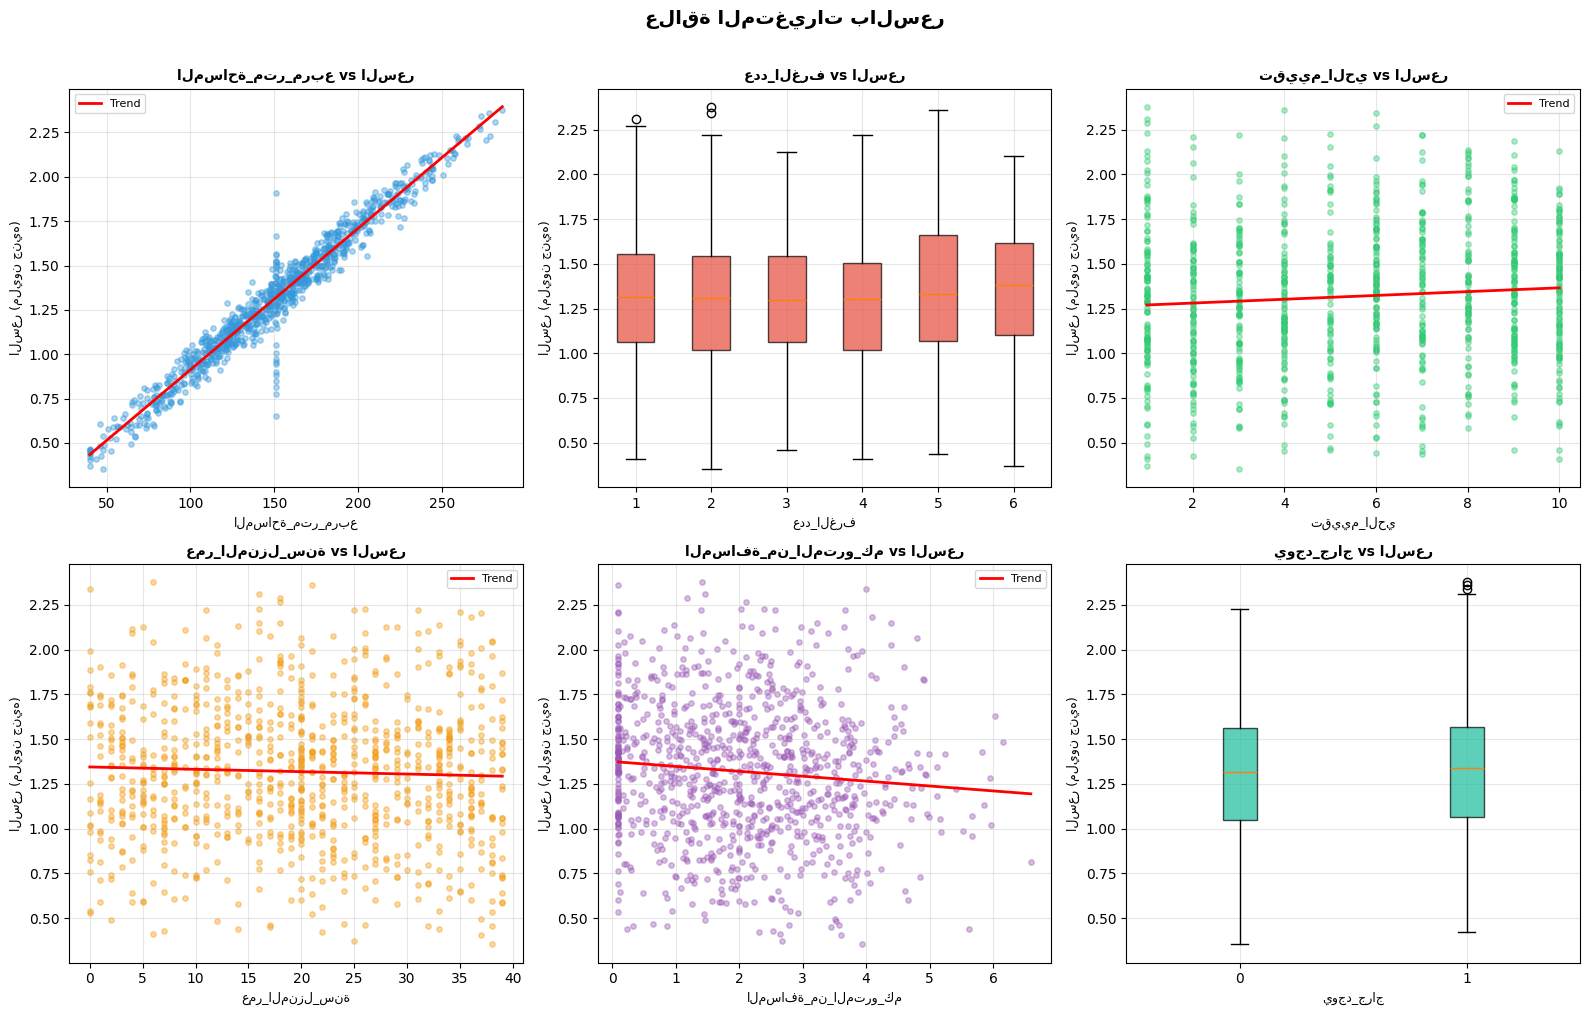

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

plot_data = [
    ('المساحة_متر_مربع', 'scatter'),
    ('عدد_الغرف', 'box'),
    ('تقييم_الحي', 'scatter'),
    ('عمر_المنزل_سنة', 'scatter'),
    ('المسافة_من_المترو_كم', 'scatter'),
    ('يوجد_جراج', 'box'),
]

colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

for i, (col, plot_type) in enumerate(plot_data):
    ax = axes[i]
    if plot_type == 'scatter':
        ax.scatter(df_clean[col], df_clean['السعر_جنيه'] / 1e6, 
                   alpha=0.4, color=colors[i], s=15)
        z = np.polyfit(df_clean[col], df_clean['السعر_جنيه'] / 1e6, 1)
        p = np.poly1d(z)
        x_line = np.linspace(df_clean[col].min(), df_clean[col].max(), 100)
        ax.plot(x_line, p(x_line), 'r-', linewidth=2, label='Trend')
        ax.legend(fontsize=8)
    else:
        groups = [df_clean[df_clean[col] == val]['السعر_جنيه'].values / 1e6 
                  for val in sorted(df_clean[col].unique())]
        ax.boxplot(groups, labels=[str(int(v)) for v in sorted(df_clean[col].unique())],
                   patch_artist=True,
                   boxprops=dict(facecolor=colors[i], alpha=0.7))
    
    ax.set_xlabel(col, fontsize=9)
    ax.set_ylabel('السعر (مليون جنيه)', fontsize=9)
    ax.set_title(f'{col} vs السعر', fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.suptitle('علاقة المتغيرات بالسعر', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


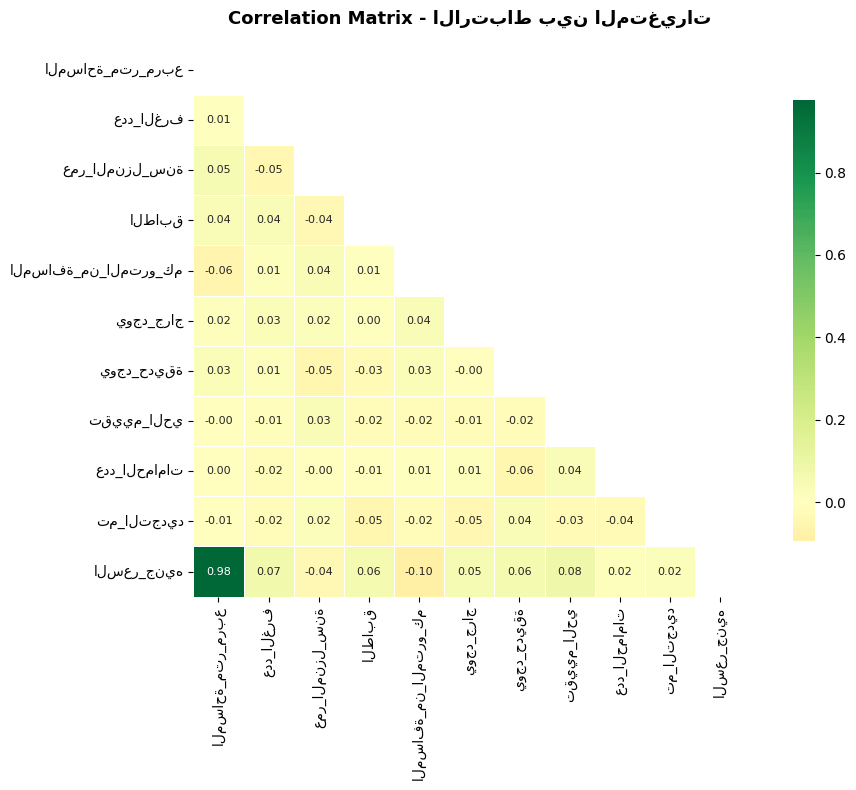

🔗 أعلى ارتباط مع السعر:
   المساحة_متر_مربع: 0.976 (↑ إيجابي)
   تقييم_الحي: 0.082 (↑ إيجابي)
   عدد_الغرف: 0.074 (↑ إيجابي)
   يوجد_حديقة: 0.062 (↑ إيجابي)
   الطابق: 0.057 (↑ إيجابي)
   يوجد_جراج: 0.047 (↑ إيجابي)
   تم_التجديد: 0.017 (↑ إيجابي)
   عدد_الحمامات: 0.016 (↑ إيجابي)
   عمر_المنزل_سنة: -0.038 (↓ سلبي)
   المسافة_من_المترو_كم: -0.096 (↓ سلبي)


In [9]:
# Correlation Heatmap
fig, ax = plt.subplots(figsize=(11, 8))
corr_matrix = df_clean.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 8}, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix - الارتباط بين المتغيرات', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# أعلى ارتباطات مع السعر
print("🔗 أعلى ارتباط مع السعر:")
price_corr = corr_matrix['السعر_جنيه'].drop('السعر_جنيه').sort_values(ascending=False)
for feat, val in price_corr.items():
    direction = "↑ إيجابي" if val > 0 else "↓ سلبي"
    print(f"   {feat}: {val:.3f} ({direction})")


## الخطوة 7 — تجهيز البيانات للنمذجة (Feature Engineering)

### الخطوات:
1. **تحديد الـ Features والـ Target**
2. **Train/Test Split**: تقسيم البيانات (80% تدريب، 20% اختبار)
3. **Feature Scaling باستخدام StandardScaler**

### معادلة StandardScaler:
$$z = \frac{x - \mu}{\sigma}$$

حيث:
- $x$ = القيمة الأصلية
- $\mu$ = المتوسط (Mean)
- $\sigma$ = الانحراف المعياري (Std)

**لماذا نعمل Scaling؟** لأن الـ Features بتكون بمقاييس مختلفة (مثلاً: المساحة 40-400 متر، بينما الجراج 0 أو 1)، والـ Scaling بيخلي الكل على نفس المقياس ويحسن أداء النموذج.


In [10]:
# تحديد Features و Target
feature_cols = [
    'المساحة_متر_مربع', 'عدد_الغرف', 'عمر_المنزل_سنة', 'الطابق',
    'المسافة_من_المترو_كم', 'يوجد_جراج', 'يوجد_حديقة',
    'تقييم_الحي', 'عدد_الحمامات', 'تم_التجديد'
]
target_col = 'السعر_جنيه'

X = df_clean[feature_cols]
y = df_clean[target_col]

print(f"✅ Features shape: {X.shape}")
print(f"✅ Target shape:   {y.shape}")
print(f"\n📋 الـ Features المستخدمة:")
for i, col in enumerate(feature_cols, 1):
    print(f"   {i}. {col}")

# Train/Test Split - 80% تدريب، 20% اختبار
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\n📊 تقسيم البيانات:")
print(f"   Training set:  {X_train.shape[0]:,} عينة ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"   Testing set:   {X_test.shape[0]:,} عينة ({X_test.shape[0]/len(X)*100:.0f}%)")

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"\n✅ تم تطبيق StandardScaler بنجاح!")
print(f"   Mean of first feature before scaling: {X_train['المساحة_متر_مربع'].mean():.2f}")
print(f"   Mean of first feature after scaling:  {X_train_scaled[:, 0].mean():.4f}")


✅ Features shape: (978, 10)
✅ Target shape:   (978,)

📋 الـ Features المستخدمة:
   1. المساحة_متر_مربع
   2. عدد_الغرف
   3. عمر_المنزل_سنة
   4. الطابق
   5. المسافة_من_المترو_كم
   6. يوجد_جراج
   7. يوجد_حديقة
   8. تقييم_الحي
   9. عدد_الحمامات
   10. تم_التجديد

📊 تقسيم البيانات:
   Training set:  782 عينة (80%)
   Testing set:   196 عينة (20%)

✅ تم تطبيق StandardScaler بنجاح!
   Mean of first feature before scaling: 151.57
   Mean of first feature after scaling:  0.0000


## الخطوة 8 — إعداد MLflow للتتبع

**MLflow** هو Platform مفتوح المصدر لتتبع تجارب الـ Machine Learning.

### المزايا:
- تسجيل جميع المعاملات (Parameters) والنتائج (Metrics) تلقائيًا
- مقارنة النماذج المختلفة بسهولة
- حفظ النماذج والـ Artifacts
- واجهة مرئية لعرض النتائج

### كيفية التشغيل:
```bash
mlflow ui
```
ثم افتح المتصفح على: **http://localhost:5000**


In [11]:
import mlflow
import mlflow.sklearn

# إعداد MLflow
mlflow.set_tracking_uri("mlruns")
mlflow.set_experiment("House_Price_Prediction_Egypt")

print("✅ تم إعداد MLflow!")
print(f"   Experiment: House_Price_Prediction_Egypt")
print(f"   Tracking URI: mlruns/")
print(f"\n💡 لرؤية النتائج، شغّل في الـ Terminal:")
print(f"   mlflow ui")
print(f"   ثم افتح: http://localhost:5000")

# دالة مساعدة لحساب المقاييس
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name="Model"):
    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)
    
    metrics = {
        'train_mae':  mean_absolute_error(y_train, y_pred_train),
        'test_mae':   mean_absolute_error(y_test,  y_pred_test),
        'train_mse':  mean_squared_error(y_train,  y_pred_train),
        'test_mse':   mean_squared_error(y_test,   y_pred_test),
        'train_rmse': np.sqrt(mean_squared_error(y_train, y_pred_train)),
        'test_rmse':  np.sqrt(mean_squared_error(y_test,  y_pred_test)),
        'train_r2':   r2_score(y_train, y_pred_train),
        'test_r2':    r2_score(y_test,  y_pred_test),
    }
    
    print(f"\n{'='*55}")
    print(f"  📊 نتائج: {model_name}")
    print(f"{'='*55}")
    print(f"  {'المقياس':<25} {'Train':>12} {'Test':>12}")
    print(f"  {'-'*50}")
    print(f"  {'MAE (جنيه)':<25} {metrics['train_mae']:>12,.0f} {metrics['test_mae']:>12,.0f}")
    print(f"  {'RMSE (جنيه)':<25} {metrics['train_rmse']:>12,.0f} {metrics['test_rmse']:>12,.0f}")
    print(f"  {'R² Score':<25} {metrics['train_r2']:>12.4f} {metrics['test_r2']:>12.4f}")
    print(f"{'='*55}")
    return metrics, y_pred_test

print("\n✅ تم تعريف دالة التقييم بنجاح!")


✅ تم إعداد MLflow!
   Experiment: House_Price_Prediction_Egypt
   Tracking URI: mlruns/

💡 لرؤية النتائج، شغّل في الـ Terminal:
   mlflow ui
   ثم افتح: http://localhost:5000

✅ تم تعريف دالة التقييم بنجاح!


## الخطوة 9 — Linear Regression

### المعادلة الأساسية:
$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_n x_n$$

حيث:
- $\hat{y}$ = السعر المتوقع
- $\beta_0$ = الـ Intercept (ثابت)
- $\beta_1, \beta_2, ..., \beta_n$ = الـ Coefficients (معاملات كل Feature)

### دالة الخسارة (Loss Function) - MSE:
$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

### مقاييس التقييم:
- **MAE** (Mean Absolute Error): $\frac{1}{n}\sum|y_i - \hat{y}_i|$ — متوسط الخطأ المطلق
- **RMSE** (Root Mean Squared Error): $\sqrt{\frac{1}{n}\sum(y_i-\hat{y}_i)^2}$ — جذر متوسط الخطأ التربيعي
- **R² Score**: $1 - \frac{SS_{res}}{SS_{tot}}$ — نسبة التباين المفسَّر (كلما اقترب من 1 كلما كان أفضل)


In [12]:
results = {}  # لتخزين نتائج كل النماذج

with mlflow.start_run(run_name="Linear_Regression"):
    # بناء النموذج
    lr = LinearRegression()
    lr.fit(X_train_scaled, y_train)
    
    # التقييم
    metrics, y_pred_lr = evaluate_model(
        lr, X_train_scaled, X_test_scaled, y_train, y_test,
        "Linear Regression"
    )
    results['Linear Regression'] = metrics
    
    # تسجيل في MLflow
    mlflow.log_params({"model": "LinearRegression", "scaler": "StandardScaler"})
    mlflow.log_metrics({
        "train_mae":  metrics['train_mae'],
        "test_mae":   metrics['test_mae'],
        "train_rmse": metrics['train_rmse'],
        "test_rmse":  metrics['test_rmse'],
        "train_r2":   metrics['train_r2'],
        "test_r2":    metrics['test_r2'],
    })
    mlflow.sklearn.log_model(lr, "linear_regression_model")

# أهم الـ Coefficients
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', ascending=False)

print("\n🔍 معاملات النموذج (Feature Importance):")
print(coef_df.to_string(index=False))
print(f"\n   Intercept (β₀) = {lr.intercept_:,.0f}")


2026/05/08 18:16:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



  📊 نتائج: Linear Regression
  المقياس                          Train         Test
  --------------------------------------------------
  MAE (جنيه)                      25,404       24,275
  RMSE (جنيه)                     58,821       61,313
  R² Score                        0.9775       0.9727


2026/05/08 18:16:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



🔍 معاملات النموذج (Feature Importance):
             Feature   Coefficient
    المساحة_متر_مربع 383801.783123
          تقييم_الحي  36458.417711
           عدد_الغرف  24693.497668
           يوجد_جراج  15087.857212
          تم_التجديد  13524.414567
          يوجد_حديقة  11965.649258
              الطابق   8635.132508
        عدد_الحمامات   5345.402734
المسافة_من_المترو_كم -12236.232796
      عمر_المنزل_سنة -33044.782502

   Intercept (β₀) = 1,322,721


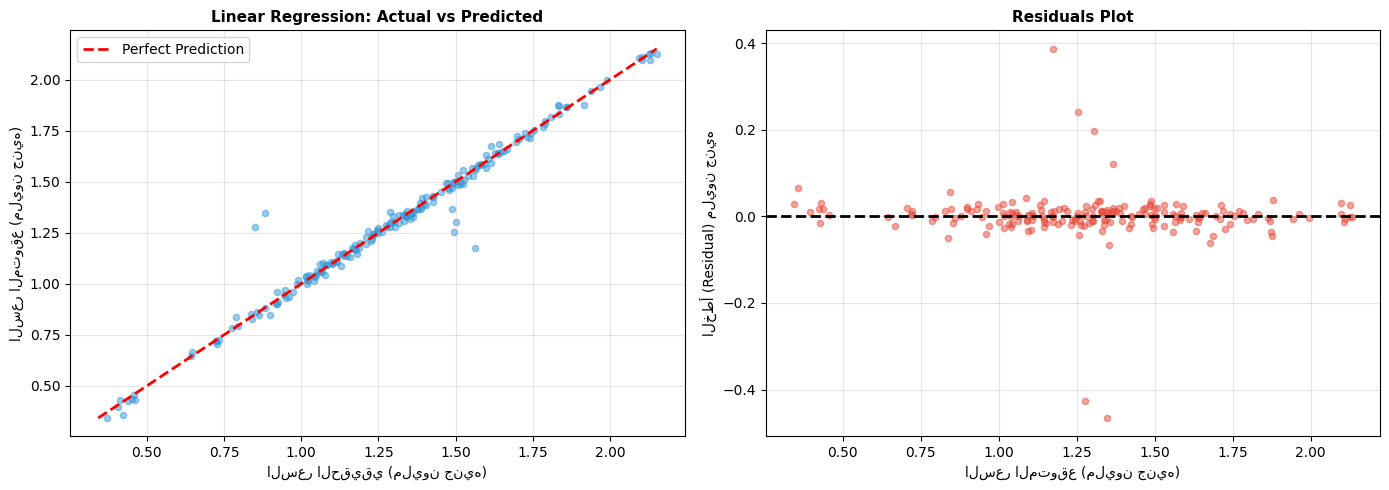

✅ Linear Regression - R² = 0.9727


In [13]:
# رسم النتائج - Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs Predicted
y_pred_lr_all = lr.predict(X_test_scaled)
axes[0].scatter(y_test/1e6, y_pred_lr_all/1e6, alpha=0.5, color='#3498db', s=20)
min_val = min(y_test.min(), y_pred_lr_all.min()) / 1e6
max_val = max(y_test.max(), y_pred_lr_all.max()) / 1e6
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('السعر الحقيقي (مليون جنيه)', fontsize=10)
axes[0].set_ylabel('السعر المتوقع (مليون جنيه)', fontsize=10)
axes[0].set_title('Linear Regression: Actual vs Predicted', fontsize=11, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Residuals
residuals = y_test - y_pred_lr_all
axes[1].scatter(y_pred_lr_all/1e6, residuals/1e6, alpha=0.5, color='#e74c3c', s=20)
axes[1].axhline(y=0, color='black', linestyle='--', lw=2)
axes[1].set_xlabel('السعر المتوقع (مليون جنيه)', fontsize=10)
axes[1].set_ylabel('الخطأ (Residual) مليون جنيه', fontsize=10)
axes[1].set_title('Residuals Plot', fontsize=11, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('linear_regression_results.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Linear Regression - R² = {results['Linear Regression']['test_r2']:.4f}")


## الخطوة 10 — Ridge Regression (L2 Regularization)

### لماذا نحتاج Regularization؟
الـ **Linear Regression** العادي ممكن يعاني من **Overfitting** (التحفظ الزائد)، حيث يحفظ الداتا بدل ما يتعلم منها.

### الفرق عن Linear Regression:
**Linear Regression** بيقلل:
$$\text{MSE} = \frac{1}{n} \sum (y_i - \hat{y}_i)^2$$

**Ridge** بيقلل:
$$\text{Loss} = \frac{1}{n} \sum (y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^{p} \beta_j^2$$

- $\alpha$ (alpha) = معامل التنظيم (كلما زاد، زادت العقوبة على الـ Coefficients الكبيرة)
- الـ Ridge بيقلل الـ Coefficients بس ما بيحذفها (ما بيوصلش للصفر)

### متى نستخدمه؟
لما يكون فيه **Multicollinearity** (ارتباط بين الـ Features).


In [14]:
with mlflow.start_run(run_name="Ridge_Regression"):
    ridge = Ridge(alpha=100)  # alpha هو قوة الـ Regularization
    ridge.fit(X_train_scaled, y_train)
    
    metrics_ridge, y_pred_ridge = evaluate_model(
        ridge, X_train_scaled, X_test_scaled, y_train, y_test,
        "Ridge Regression (alpha=100)"
    )
    results['Ridge Regression'] = metrics_ridge
    
    # تسجيل في MLflow
    mlflow.log_params({"model": "Ridge", "alpha": 100, "scaler": "StandardScaler"})
    mlflow.log_metrics({
        "train_mae": metrics_ridge['train_mae'],
        "test_mae":  metrics_ridge['test_mae'],
        "train_r2":  metrics_ridge['train_r2'],
        "test_r2":   metrics_ridge['test_r2'],
        "train_rmse": metrics_ridge['train_rmse'],
        "test_rmse":  metrics_ridge['test_rmse'],
    })
    mlflow.sklearn.log_model(ridge, "ridge_model")

# مقارنة الـ Coefficients
coef_compare = pd.DataFrame({
    'Feature': feature_cols,
    'Linear Reg': lr.coef_,
    'Ridge': ridge.coef_
}).round(0)
print("\n📊 مقارنة الـ Coefficients (Linear vs Ridge):")
print(coef_compare.to_string(index=False))


2026/05/08 18:17:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



  📊 نتائج: Ridge Regression (alpha=100)
  المقياس                          Train         Test
  --------------------------------------------------
  MAE (جنيه)                      47,290       45,474
  RMSE (جنيه)                     73,702       73,147
  R² Score                        0.9647       0.9612


2026/05/08 18:17:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



📊 مقارنة الـ Coefficients (Linear vs Ridge):
             Feature  Linear Reg    Ridge
    المساحة_متر_مربع    383802.0 339514.0
           عدد_الغرف     24693.0  22950.0
      عمر_المنزل_سنة    -33045.0 -25649.0
              الطابق      8635.0   9542.0
المسافة_من_المترو_كم    -12236.0 -14223.0
           يوجد_جراج     15088.0  14058.0
          يوجد_حديقة     11966.0  12143.0
          تقييم_الحي     36458.0  31866.0
        عدد_الحمامات      5345.0   4735.0
          تم_التجديد     13524.0  10728.0


## الخطوة 11 — Lasso Regression (L1 Regularization)

### الفرق عن Ridge:
**Lasso** بيقلل:
$$\text{Loss} = \frac{1}{n} \sum (y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^{p} |\beta_j|$$

الفرق الأساسي: Lasso بيستخدم **القيمة المطلقة** بدل التربيع، وده بيخليه يقدر يحوّل بعض الـ Coefficients لـ **صفر تمامًا**.

### ميزة Lasso:
- **Feature Selection تلقائي**: الـ Features الأقل أهمية بتاخد Coefficient = 0 وبتتحذف تلقائيًا
- مفيد لما يكون فيه كتير من الـ Features غير المهمة

| | Ridge (L2) | Lasso (L1) |
|--|--|--|
| العقوبة | $\sum \beta_j^2$ | $\sum \|\beta_j\|$ |
| نتيجة | يقلل الـ Coefficients | يقلل ويحذف الـ Coefficients |
| Feature Selection | ❌ لا | ✅ نعم |


In [15]:
with mlflow.start_run(run_name="Lasso_Regression"):
    lasso = Lasso(alpha=1000, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)
    
    metrics_lasso, y_pred_lasso = evaluate_model(
        lasso, X_train_scaled, X_test_scaled, y_train, y_test,
        "Lasso Regression (alpha=1000)"
    )
    results['Lasso Regression'] = metrics_lasso
    
    mlflow.log_params({"model": "Lasso", "alpha": 1000, "scaler": "StandardScaler"})
    mlflow.log_metrics({
        "train_mae": metrics_lasso['train_mae'],
        "test_mae":  metrics_lasso['test_mae'],
        "train_r2":  metrics_lasso['train_r2'],
        "test_r2":   metrics_lasso['test_r2'],
        "train_rmse": metrics_lasso['train_rmse'],
        "test_rmse":  metrics_lasso['test_rmse'],
    })
    mlflow.sklearn.log_model(lasso, "lasso_model")

# Features التي أصبح معاملها صفر (محذوفة تلقائيًا)
zero_coef = [f for f, c in zip(feature_cols, lasso.coef_) if abs(c) < 0.1]
nonzero_coef = [f for f, c in zip(feature_cols, lasso.coef_) if abs(c) >= 0.1]
print(f"\n🔍 Lasso Feature Selection:")
print(f"   ✅ Features مهمة ({len(nonzero_coef)}): {nonzero_coef}")
print(f"   ❌ Features محذوفة ({len(zero_coef)}): {zero_coef if zero_coef else 'لا يوجد'}")


2026/05/08 18:17:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



  📊 نتائج: Lasso Regression (alpha=1000)
  المقياس                          Train         Test
  --------------------------------------------------
  MAE (جنيه)                      25,323       24,330
  RMSE (جنيه)                     58,904       61,026
  R² Score                        0.9775       0.9730


2026/05/08 18:17:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



🔍 Lasso Feature Selection:
   ✅ Features مهمة (10): ['المساحة_متر_مربع', 'عدد_الغرف', 'عمر_المنزل_سنة', 'الطابق', 'المسافة_من_المترو_كم', 'يوجد_جراج', 'يوجد_حديقة', 'تقييم_الحي', 'عدد_الحمامات', 'تم_التجديد']
   ❌ Features محذوفة (0): لا يوجد


## الخطوة 12 — ElasticNet Regression (L1 + L2)

### المعادلة:
$$\text{Loss} = \frac{1}{n} \sum (y_i - \hat{y}_i)^2 + \alpha \left[ \rho \sum_{j=1}^{p}|\beta_j| + \frac{(1-\rho)}{2} \sum_{j=1}^{p} \beta_j^2 \right]$$

حيث:
- $\alpha$ = قوة الـ Regularization الكلية
- $\rho$ (l1_ratio) = نسبة الـ L1 (Lasso) بالنسبة للـ L2 (Ridge)
  - إذا $\rho = 1$ ← Lasso فقط
  - إذا $\rho = 0$ ← Ridge فقط
  - إذا $0 < \rho < 1$ ← مزيج منهما

### متى نستخدم ElasticNet؟
لما نريد **مزيج من ميزتين**:
- القدرة على **حذف Features** (من Lasso)
- **الاستقرار** في وجود Features مترابطة (من Ridge)


In [16]:
with mlflow.start_run(run_name="ElasticNet_Regression"):
    elasticnet = ElasticNet(alpha=1000, l1_ratio=0.5, max_iter=10000)
    elasticnet.fit(X_train_scaled, y_train)
    
    metrics_en, y_pred_en = evaluate_model(
        elasticnet, X_train_scaled, X_test_scaled, y_train, y_test,
        "ElasticNet (alpha=1000, l1_ratio=0.5)"
    )
    results['ElasticNet'] = metrics_en
    
    mlflow.log_params({
        "model": "ElasticNet", "alpha": 1000, 
        "l1_ratio": 0.5, "scaler": "StandardScaler"
    })
    mlflow.log_metrics({
        "train_mae": metrics_en['train_mae'],
        "test_mae":  metrics_en['test_mae'],
        "train_r2":  metrics_en['train_r2'],
        "test_r2":   metrics_en['test_r2'],
        "train_rmse": metrics_en['train_rmse'],
        "test_rmse":  metrics_en['test_rmse'],
    })
    mlflow.sklearn.log_model(elasticnet, "elasticnet_model")

print("\n✅ تم تدريب ElasticNet بنجاح!")


2026/05/08 18:17:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



  📊 نتائج: ElasticNet (alpha=1000, l1_ratio=0.5)
  المقياس                          Train         Test
  --------------------------------------------------
  MAE (جنيه)                     316,518      291,975
  RMSE (جنيه)                    391,541      371,018
  R² Score                        0.0039       0.0007


2026/05/08 18:17:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



✅ تم تدريب ElasticNet بنجاح!


## الخطوة 13 — Grid Search: إيجاد أفضل Hyperparameters

### ما هو Grid Search؟
**Grid Search** بيجرب جميع التوليفات الممكنة من الـ Hyperparameters اللي بنحددها ويختار الأفضل.

### مثال:
لو عندنا alpha = [0.1, 1, 10] وl1_ratio = [0.2, 0.5, 0.8] ← هيجرب **9 توليفات** مختلفة.

### Cross-Validation (CV):
بدل ما نقسم الداتا مرة واحدة، بنقسمها **k مرة** ونحسب متوسط الأداء:

```
|  Fold 1  |  Fold 2  |  Fold 3  |  Fold 4  |  Fold 5  |
|--Train---|--Train---|--Train---|--Train---| --Test-- |
|--Train---|--Train---|--Train---| --Test-- |--Train---|
...
```


🔎 Grid Search - Ridge Regression


2026/05/08 18:18:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



  📊 نتائج: Ridge (Best alpha=0.1)
  المقياس                          Train         Test
  --------------------------------------------------
  MAE (جنيه)                      25,406       24,269
  RMSE (جنيه)                     58,821       61,311
  R² Score                        0.9775       0.9727


2026/05/08 18:18:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



⭐ أفضل Alpha: 0.1


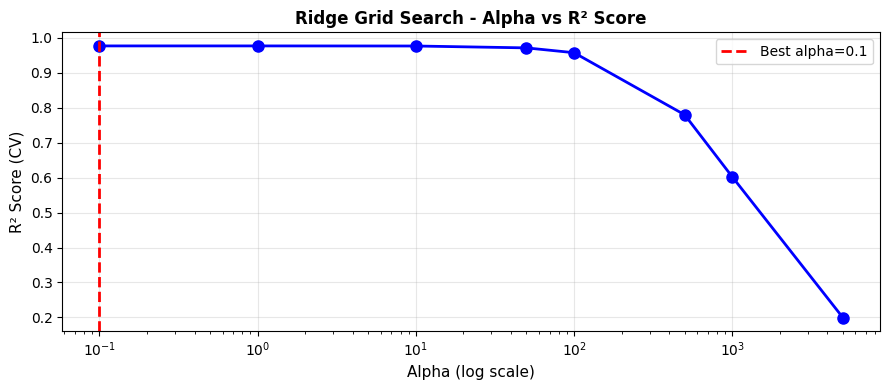

In [17]:
print("🔎 Grid Search - Ridge Regression")
print("="*50)

param_grid_ridge = {
    'alpha': [0.1, 1, 10, 50, 100, 500, 1000, 5000]
}

with mlflow.start_run(run_name="GridSearch_Ridge"):
    gs_ridge = GridSearchCV(
        Ridge(), 
        param_grid_ridge, 
        cv=5,                    # 5-Fold Cross Validation
        scoring='neg_mean_squared_error',
        n_jobs=-1,
        verbose=0
    )
    gs_ridge.fit(X_train_scaled, y_train)
    
    best_ridge = gs_ridge.best_estimator_
    best_alpha_ridge = gs_ridge.best_params_['alpha']
    
    metrics_gs_ridge, _ = evaluate_model(
        best_ridge, X_train_scaled, X_test_scaled, y_train, y_test,
        f"Ridge (Best alpha={best_alpha_ridge})"
    )
    results['Ridge (GridSearch)'] = metrics_gs_ridge
    
    mlflow.log_params({"model": "Ridge_GridSearch", "best_alpha": best_alpha_ridge, "cv": 5})
    mlflow.log_metrics({
        "test_r2": metrics_gs_ridge['test_r2'],
        "test_rmse": metrics_gs_ridge['test_rmse'],
        "test_mae": metrics_gs_ridge['test_mae'],
        "train_r2": metrics_gs_ridge['train_r2'],
        "train_rmse": metrics_gs_ridge['train_rmse'],
        "train_mae": metrics_gs_ridge['train_mae'],
    })
    mlflow.sklearn.log_model(best_ridge, "ridge_gridsearch_model")
    
    print(f"\n⭐ أفضل Alpha: {best_alpha_ridge}")
    
    # رسم نتائج Grid Search
    alphas = param_grid_ridge['alpha']
    cv_scores = []
    for alpha in alphas:
        r = Ridge(alpha=alpha)
        scores = cross_val_score(r, X_train_scaled, y_train, cv=5, scoring='r2')
        cv_scores.append(scores.mean())
    
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.semilogx(alphas, cv_scores, 'bo-', linewidth=2, markersize=8)
    best_idx = cv_scores.index(max(cv_scores))
    ax.axvline(x=alphas[best_idx], color='red', linestyle='--', lw=2, label=f'Best alpha={alphas[best_idx]}')
    ax.set_xlabel('Alpha (log scale)', fontsize=11)
    ax.set_ylabel('R² Score (CV)', fontsize=11)
    ax.set_title('Ridge Grid Search - Alpha vs R² Score', fontsize=12, fontweight='bold')
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('gridsearch_ridge.png', dpi=150, bbox_inches='tight')
    plt.show()


In [18]:
print("🔎 Grid Search - ElasticNet")
print("="*50)

param_grid_en = {
    'alpha':    [100, 500, 1000, 5000],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}
total_combinations = len(param_grid_en['alpha']) * len(param_grid_en['l1_ratio'])
print(f"   عدد التوليفات: {total_combinations} × 5 CV = {total_combinations*5} تجربة")

with mlflow.start_run(run_name="GridSearch_ElasticNet"):
    gs_en = GridSearchCV(
        ElasticNet(max_iter=10000), 
        param_grid_en, 
        cv=5, 
        scoring='neg_mean_squared_error',
        n_jobs=-1
    )
    gs_en.fit(X_train_scaled, y_train)
    
    best_en = gs_en.best_estimator_
    best_params_en = gs_en.best_params_
    
    metrics_gs_en, _ = evaluate_model(
        best_en, X_train_scaled, X_test_scaled, y_train, y_test,
        f"ElasticNet (Best params: {best_params_en})"
    )
    results['ElasticNet (GridSearch)'] = metrics_gs_en
    
    mlflow.log_params({
        "model": "ElasticNet_GridSearch", 
        "best_alpha": best_params_en['alpha'],
        "best_l1_ratio": best_params_en['l1_ratio'],
        "cv": 5
    })
    mlflow.log_metrics({
        "test_r2": metrics_gs_en['test_r2'],
        "test_rmse": metrics_gs_en['test_rmse'],
        "test_mae": metrics_gs_en['test_mae'],
        "train_r2": metrics_gs_en['train_r2'],
        "train_rmse": metrics_gs_en['train_rmse'],
        "train_mae": metrics_gs_en['train_mae'],
    })
    mlflow.sklearn.log_model(best_en, "elasticnet_gridsearch_model")
    
    print(f"\n⭐ أفضل Parameters:")
    for k, v in best_params_en.items():
        print(f"   {k} = {v}")


🔎 Grid Search - ElasticNet
   عدد التوليفات: 20 × 5 CV = 100 تجربة


2026/05/08 18:19:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



  📊 نتائج: ElasticNet (Best params: {'alpha': 100, 'l1_ratio': 0.9})
  المقياس                          Train         Test
  --------------------------------------------------
  MAE (جنيه)                     288,552      267,412
  RMSE (جنيه)                    357,148      339,115
  R² Score                        0.1712       0.1652


2026/05/08 18:19:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



⭐ أفضل Parameters:
   alpha = 100
   l1_ratio = 0.9


## الخطوة 14 — المقارنة الشاملة لجميع النماذج

الآن نقارن **كل النماذج** ونحدد الأفضل.


In [19]:
# إنشاء جدول المقارنة
comparison_data = []
for model_name, metrics in results.items():
    comparison_data.append({
        'النموذج': model_name,
        'Train R²': round(metrics['train_r2'], 4),
        'Test R²': round(metrics['test_r2'], 4),
        'Test MAE (جنيه)': int(metrics['test_mae']),
        'Test RMSE (جنيه)': int(metrics['test_rmse']),
        'Overfitting (Train-Test R²)': round(metrics['train_r2'] - metrics['test_r2'], 4)
    })

comp_df = pd.DataFrame(comparison_data).sort_values('Test R²', ascending=False)
print("\n" + "="*80)
print("  📊 جدول مقارنة شاملة لجميع النماذج")
print("="*80)
print(comp_df.to_string(index=False))

best_model_name = comp_df.iloc[0]['النموذج']
best_r2 = comp_df.iloc[0]['Test R²']
print(f"\n🏆 أفضل نموذج: {best_model_name}")
print(f"   Test R² = {best_r2:.4f} ({best_r2*100:.1f}% من التباين مُفسَّر)")



  📊 جدول مقارنة شاملة لجميع النماذج
                النموذج  Train R²  Test R²  Test MAE (جنيه)  Test RMSE (جنيه)  Overfitting (Train-Test R²)
       Lasso Regression    0.9775   0.9730            24330             61026                       0.0045
      Linear Regression    0.9775   0.9727            24275             61313                       0.0048
     Ridge (GridSearch)    0.9775   0.9727            24269             61310                       0.0048
       Ridge Regression    0.9647   0.9612            45474             73146                       0.0035
ElasticNet (GridSearch)    0.1712   0.1652           267411            339115                       0.0061
             ElasticNet    0.0039   0.0007           291975            371017                       0.0032

🏆 أفضل نموذج: Lasso Regression
   Test R² = 0.9730 (97.3% من التباين مُفسَّر)


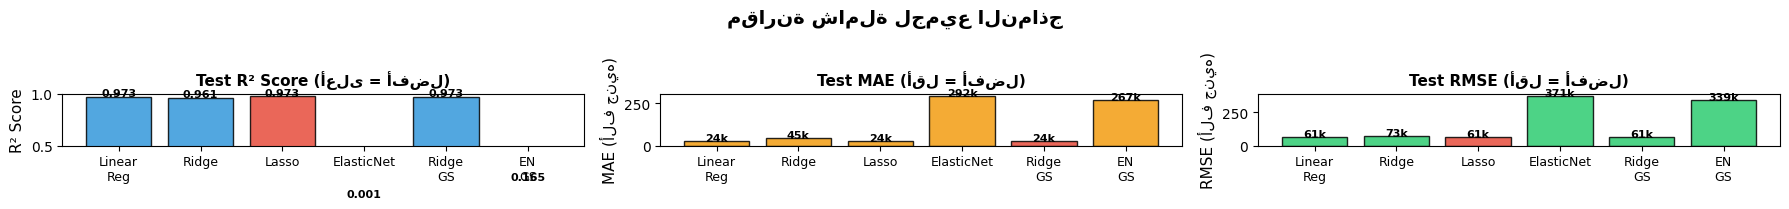

In [20]:
# رسم مقارنة شاملة
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

model_names = [r['النموذج'] for r in comparison_data]
short_names = ['Linear\nReg', 'Ridge', 'Lasso', 'ElasticNet', 'Ridge\nGS', 'EN\nGS']
test_r2  = [r['Test R²'] for r in comparison_data]
test_mae = [r['Test MAE (جنيه)'] for r in comparison_data]
test_rmse = [r['Test RMSE (جنيه)'] for r in comparison_data]

colors_bar = ['#e74c3c' if r == max(test_r2) else '#3498db' for r in test_r2]

# R² Score
bars1 = axes[0].bar(range(len(short_names)), test_r2, color=colors_bar, edgecolor='black', alpha=0.85)
axes[0].set_xticks(range(len(short_names)))
axes[0].set_xticklabels(short_names, fontsize=9)
axes[0].set_ylabel('R² Score', fontsize=11)
axes[0].set_title('Test R² Score (أعلى = أفضل)', fontsize=11, fontweight='bold')
axes[0].set_ylim(0.5, 1.0)
for bar, val in zip(bars1, test_r2):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003, f'{val:.3f}', 
                ha='center', fontsize=8, fontweight='bold')

# MAE
colors_mae = ['#e74c3c' if r == min(test_mae) else '#f39c12' for r in test_mae]
bars2 = axes[1].bar(range(len(short_names)), [m/1000 for m in test_mae], color=colors_mae, edgecolor='black', alpha=0.85)
axes[1].set_xticks(range(len(short_names)))
axes[1].set_xticklabels(short_names, fontsize=9)
axes[1].set_ylabel('MAE (ألف جنيه)', fontsize=11)
axes[1].set_title('Test MAE (أقل = أفضل)', fontsize=11, fontweight='bold')
for bar, val in zip(bars2, test_mae):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'{val/1000:.0f}k', 
                ha='center', fontsize=8, fontweight='bold')

# RMSE
colors_rmse = ['#e74c3c' if r == min(test_rmse) else '#2ecc71' for r in test_rmse]
bars3 = axes[2].bar(range(len(short_names)), [m/1000 for m in test_rmse], color=colors_rmse, edgecolor='black', alpha=0.85)
axes[2].set_xticks(range(len(short_names)))
axes[2].set_xticklabels(short_names, fontsize=9)
axes[2].set_ylabel('RMSE (ألف جنيه)', fontsize=11)
axes[2].set_title('Test RMSE (أقل = أفضل)', fontsize=11, fontweight='bold')
for bar, val in zip(bars3, test_rmse):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'{val/1000:.0f}k', 
                ha='center', fontsize=8, fontweight='bold')

plt.suptitle('مقارنة شاملة لجميع النماذج', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## الخطوة 15 — اختبار النموذج الأفضل على بيانات جديدة

نجرب نتنبأ بسعر شقة جديدة لم يرها النموذج قبل.


In [21]:
# اختبار عملي - تنبؤ بسعر شقق جديدة

test_apartments = pd.DataFrame([
    {
        'المساحة_متر_مربع': 120, 'عدد_الغرف': 3, 'عمر_المنزل_سنة': 5, 'الطابق': 4,
        'المسافة_من_المترو_كم': 1.5, 'يوجد_جراج': 1, 'يوجد_حديقة': 0,
        'تقييم_الحي': 8, 'عدد_الحمامات': 2, 'تم_التجديد': 1,
        'الوصف': 'شقة حديثة بجراج وتقييم حي عالي'
    },
    {
        'المساحة_متر_مربع': 60, 'عدد_الغرف': 2, 'عمر_المنزل_سنة': 25, 'الطابق': 1,
        'المسافة_من_المترو_كم': 5.0, 'يوجد_جراج': 0, 'يوجد_حديقة': 0,
        'تقييم_الحي': 4, 'عدد_الحمامات': 1, 'تم_التجديد': 0,
        'الوصف': 'شقة قديمة بعيدة عن المترو'
    },
    {
        'المساحة_متر_مربع': 250, 'عدد_الغرف': 5, 'عمر_المنزل_سنة': 2, 'الطابق': 10,
        'المسافة_من_المترو_كم': 0.5, 'يوجد_جراج': 1, 'يوجد_حديقة': 1,
        'تقييم_الحي': 10, 'عدد_الحمامات': 3, 'تم_التجديد': 1,
        'الوصف': 'شقة فاخرة واسعة بموقع ممتاز'
    },
])

X_new = test_apartments[feature_cols]
X_new_scaled = scaler.transform(X_new)

# استخدام أفضل نموذج (Ridge GridSearch)
y_pred_new = best_ridge.predict(X_new_scaled)

print("🏠 توقعات أسعار الشقق الجديدة:")
print("=" * 60)
for i, (_, row) in enumerate(test_apartments.iterrows()):
    print(f"\nشقة {i+1}: {row['الوصف']}")
    print(f"   المساحة: {row['المساحة_متر_مربع']} م² | الغرف: {row['عدد_الغرف']} | العمر: {row['عمر_المنزل_سنة']} سنة")
    print(f"   💰 السعر المتوقع: {y_pred_new[i]:,.0f} جنيه ({y_pred_new[i]/1e6:.2f} مليون)")
print("=" * 60)


🏠 توقعات أسعار الشقق الجديدة:

شقة 1: شقة حديثة بجراج وتقييم حي عالي
   المساحة: 120 م² | الغرف: 3 | العمر: 5 سنة
   💰 السعر المتوقع: 1,153,830 جنيه (1.15 مليون)

شقة 2: شقة قديمة بعيدة عن المترو
   المساحة: 60 م² | الغرف: 2 | العمر: 25 سنة
   💰 السعر المتوقع: 452,413 جنيه (0.45 مليون)

شقة 3: شقة فاخرة واسعة بموقع ممتاز
   المساحة: 250 م² | الغرف: 5 | العمر: 2 سنة
   💰 السعر المتوقع: 2,306,695 جنيه (2.31 مليون)


## الخطوة 16 — الخلاصة والتوصيات النهائية


In [22]:
print("=" * 65)
print("  📊 ملخص المشروع الكامل")
print("=" * 65)
print(f"  الداتا: أسعار شقق في مصر ({len(df_clean):,} شقة بعد التنظيف)")
print(f"  الهدف: التنبؤ بسعر الشقة (Regression)")
print()
print("  مراحل المشروع:")
print("  ✅ 1. تحميل واستكشاف البيانات (EDA)")
print("  ✅ 2. معالجة القيم المفقودة (Median Imputation)")
print("  ✅ 3. إزالة الـ Outliers (IQR Method)")  
print("  ✅ 4. Feature Scaling (StandardScaler)")
print("  ✅ 5. Train/Test Split (80/20)")
print("  ✅ 6. Linear Regression + Evaluation")
print("  ✅ 7. Ridge Regression (L2 Regularization)")
print("  ✅ 8. Lasso Regression (L1 Regularization)")
print("  ✅ 9. ElasticNet (L1 + L2)")
print("  ✅ 10. Grid Search (Ridge + ElasticNet)")
print("  ✅ 11. MLflow Tracking لجميع النماذج")
print()
print("  نتائج النماذج:")
for _, row in comp_df.iterrows():
    marker = "🏆" if row['النموذج'] == best_model_name else "  "
    print(f"  {marker} {row['النموذج']:<25} R²={row['Test R²']:.4f}  MAE={row['Test MAE (جنيه)']/1000:.0f}k جنيه")
print()
print(f"  🏆 الفائز: {best_model_name}")
print(f"     R² = {best_r2:.4f} → النموذج يفسر {best_r2*100:.1f}% من تباين الأسعار")
print()
print("  💡 لمشاهدة النتائج على MLflow:")
print("     $ mlflow ui")
print("     ثم افتح: http://localhost:5000")
print("=" * 65)


  📊 ملخص المشروع الكامل
  الداتا: أسعار شقق في مصر (978 شقة بعد التنظيف)
  الهدف: التنبؤ بسعر الشقة (Regression)

  مراحل المشروع:
  ✅ 1. تحميل واستكشاف البيانات (EDA)
  ✅ 2. معالجة القيم المفقودة (Median Imputation)
  ✅ 3. إزالة الـ Outliers (IQR Method)
  ✅ 4. Feature Scaling (StandardScaler)
  ✅ 5. Train/Test Split (80/20)
  ✅ 6. Linear Regression + Evaluation
  ✅ 7. Ridge Regression (L2 Regularization)
  ✅ 8. Lasso Regression (L1 Regularization)
  ✅ 9. ElasticNet (L1 + L2)
  ✅ 10. Grid Search (Ridge + ElasticNet)
  ✅ 11. MLflow Tracking لجميع النماذج

  نتائج النماذج:
  🏆 Lasso Regression          R²=0.9730  MAE=24k جنيه
     Linear Regression         R²=0.9727  MAE=24k جنيه
     Ridge (GridSearch)        R²=0.9727  MAE=24k جنيه
     Ridge Regression          R²=0.9612  MAE=45k جنيه
     ElasticNet (GridSearch)   R²=0.1652  MAE=267k جنيه
     ElasticNet                R²=0.0007  MAE=292k جنيه

  🏆 الفائز: Lasso Regression
     R² = 0.9730 → النموذج يفسر 97.3% من تباين الأسعار

  💡 